In [19]:
from experiments.utils import load_data, split_data, preprocess 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
df, X, y = load_data()
X_train, _, X_test, y_train, _, y_test = split_data(X, y)

X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

print("Liczba przykładów:")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  testowych      7,903


### Baseline - wynika na zbiorze testowym 

In [4]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("log_reg", LogisticRegression(max_iter=1_000))
])
baseline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('log_reg', LogisticRegression(max_iter=1000))])

In [15]:
y_test_pred = baseline.predict(X_test)
f1_macro = f1_score(y_test, y_test_pred, average='macro')

print(classification_report(y_test, y_test_pred))
print(f"F1 macro: {f1_macro:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.83      0.73      0.78       576
             Bipolar       0.91      0.66      0.76       417
          Depression       0.69      0.76      0.72      2311
              Normal       0.87      0.95      0.91      2452
Personality disorder       0.87      0.45      0.59       161
              Stress       0.65      0.44      0.52       388
            Suicidal       0.71      0.67      0.69      1598

            accuracy                           0.77      7903
           macro avg       0.79      0.66      0.71      7903
        weighted avg       0.77      0.77      0.77      7903

F1 macro: 0.71


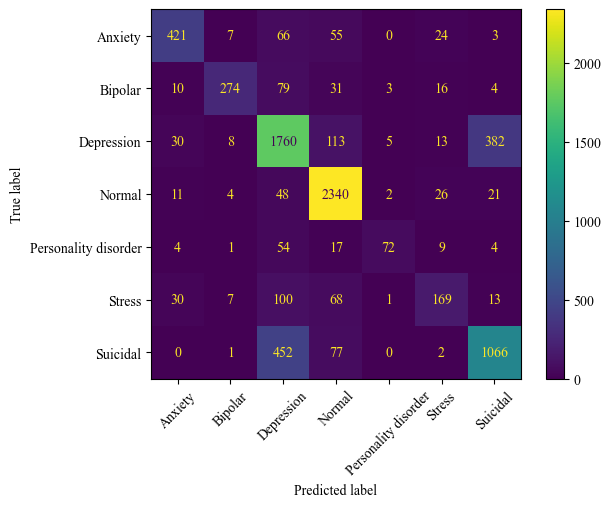

In [6]:
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    xticks_rotation=45)

### Najlepszy wariant - wynika na zbiorze testowym 
- TF-IDF z użyciem bigramów 
- klasyfikator SVM

In [7]:
bi_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LinearSVC())
])
bi_svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('clf', LinearSVC())])

In [22]:
y_test_pred_bi_svm = bi_svm_pipeline.predict(X_test)
f1_macro_bi_svm = f1_score(y_test, y_test_pred_bi_svm, average='macro')

print(classification_report(y_test, y_test_pred_bi_svm))
print(f"F1 macro: {f1_macro_bi_svm:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.84      0.80      0.82       576
             Bipolar       0.91      0.77      0.83       417
          Depression       0.71      0.75      0.73      2311
              Normal       0.90      0.95      0.93      2452
Personality disorder       0.92      0.60      0.73       161
              Stress       0.74      0.50      0.60       388
            Suicidal       0.70      0.70      0.70      1598

            accuracy                           0.79      7903
           macro avg       0.82      0.73      0.76      7903
        weighted avg       0.79      0.79      0.79      7903

F1 macro: 0.76


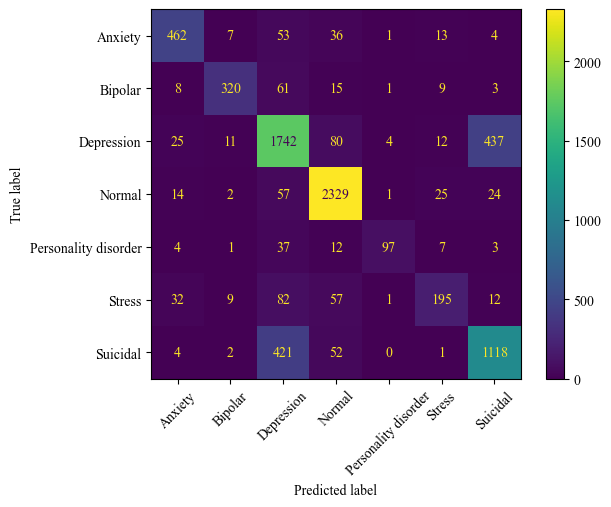

In [10]:
cm_bi_svm = confusion_matrix(y_test, y_test_pred_bi_svm)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_bi_svm,
    xticks_rotation=45)

### Zestawieni wyników

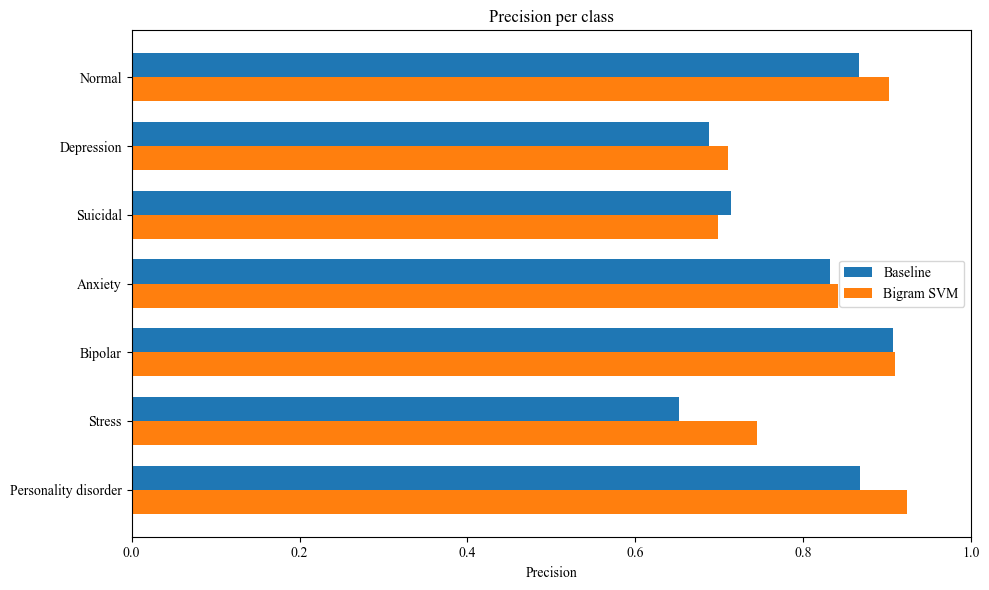

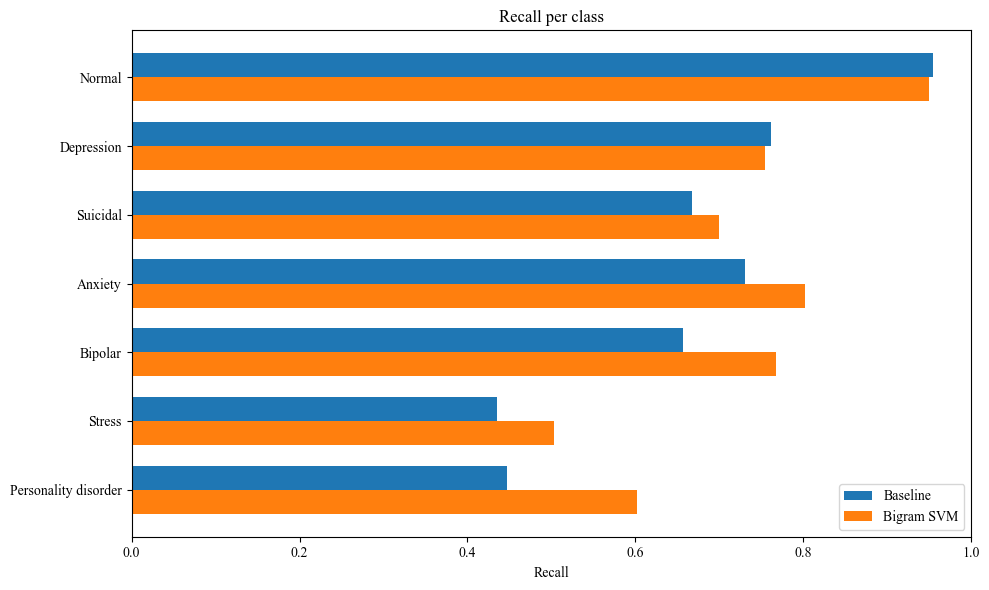

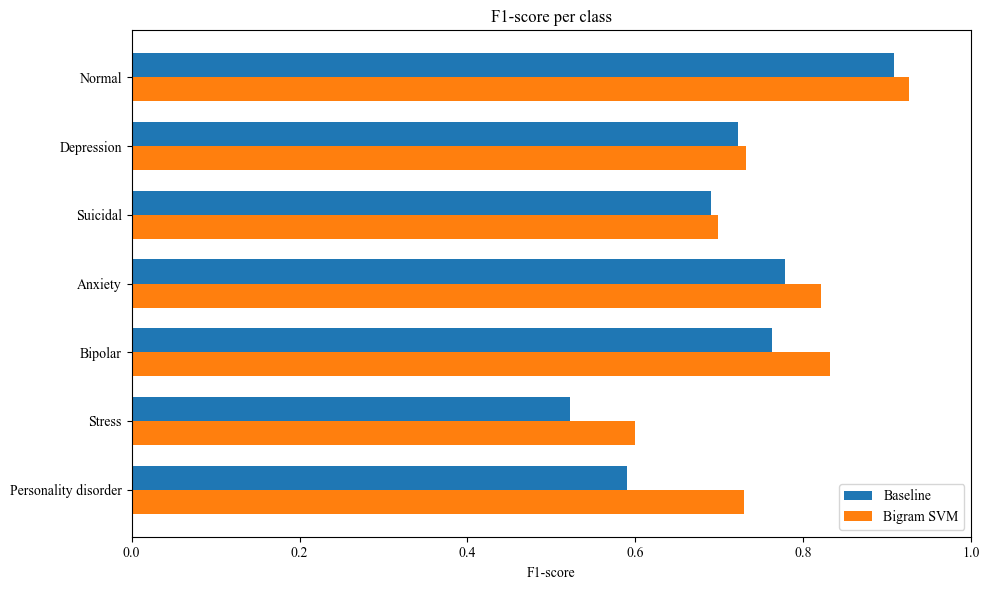

<Figure size 640x480 with 0 Axes>

In [26]:
report = classification_report(y_test, y_test_pred, output_dict=True)
report_bi_svm = classification_report(y_test, y_test_pred_bi_svm, output_dict=True)

df_base = pd.DataFrame(report).transpose()
df_bi = pd.DataFrame(report_bi_svm).transpose()

classes = [
    c for c in df_base.index
    if c not in ["accuracy", "macro avg", "weighted avg"]
]
classes = sorted(
    classes,
    key=lambda x: df_base.loc[x, "support"]
)
metrics = ["precision", "recall", "f1-score"]

for metric in metrics:
    base_values = [df_base.loc[c, metric] for c in classes]
    bi_values = [df_bi.loc[c, metric] for c in classes]

    y = np.arange(len(classes))
    h = 0.35

    plt.figure(figsize=(10, 6))
    plt.barh(y + h/2, base_values, height=h, label="Baseline")
    plt.barh(y - h/2, bi_values, height=h, label="Bigram SVM")

    plt.yticks(y, classes)
    plt.xlabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} per class")

    plt.xlim(0, 1)

    plt.legend()
    plt.tight_layout()
    plt.show()

plt.tight_layout()
plt.show()